In [21]:
!pip install mne PyWavelets scikit-learn tensorflow

In [22]:
import os
import numpy as np
import mne
import pywt
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [23]:
from google.colab import files

uploaded = files.upload()


Saving chb08_02.edf to chb08_02 (1).edf
Saving chb08_05.edf to chb08_05.edf
Saving chb08_11.edf to chb08_11.edf


In [24]:
data_dir = "/content"
edf_infos = {
    "chb08_02.edf": [(2670, 2841)],
    "chb08_05.edf": [(2856, 3046)],
    "chb08_11.edf": [(2988, 3122)],
}


In [25]:
def generate_segments_from_file(
    eeg_path,
    seizures,
    segment_len_sec=5,
    max_normal=50,
    max_seizure=100
):
    raw = mne.io.read_raw_edf(eeg_path, preload=True, verbose=False)
    data = raw.get_data()
    sfreq = int(raw.info["sfreq"])

    X = []
    y = []

    n_channels, n_samples = data.shape
    seg_samples = segment_len_sec * sfreq
    total_segments = n_samples // seg_samples

    seizure_count = 0
    normal_count = 0

    for i in range(total_segments):
        start_idx = i * seg_samples
        end_idx = start_idx + seg_samples

        start_sec = start_idx / sfreq
        end_sec = end_idx / sfreq

        label = 0

        for sz_start, sz_end in seizures:
            if end_sec > sz_start and start_sec < sz_end:
                label = 1
                break

        if label == 1:
            if seizure_count >= max_seizure:
                continue
            seizure_count += 1
        else:
            if normal_count >= max_normal:
                continue
            normal_count += 1

        segment = data[:, start_idx:end_idx]

        X.append(segment)
        y.append(label)

    print("path:", os.path.basename(eeg_path))
    print("  seizure:", seizure_count)
    print("  normal:", normal_count)

    return X, y

In [26]:
all_segments = []
all_labels = []

for edf_name, seizures in edf_infos.items():
    eeg_path = os.path.join(data_dir, edf_name)

    if not os.path.exists(eeg_path):
        print("no exist:", eeg_path)
        continue

    X_part, y_part = generate_segments_from_file(
        eeg_path=eeg_path,
        seizures=seizures,
        segment_len_sec=5,
        max_normal=30,
        max_seizure=100
    )

    all_segments.extend(X_part)
    all_labels.extend(y_part)


X_segments = np.array(all_segments)
y_segments = np.array(all_labels)

print("X_segments.shape:", X_segments.shape)
print("y_segments.shape:", y_segments.shape)
print("y_segments=1:", np.sum(y_segments == 1))
print("y_segments=0:", np.sum(y_segments == 0))

/tmp/ipykernel_17640/2058691959.py:8: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(eeg_path, preload=True, verbose=False)


path: chb08_02.edf
  seizure: 35
  normal: 30


/tmp/ipykernel_17640/2058691959.py:8: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(eeg_path, preload=True, verbose=False)


path: chb08_05.edf
  seizure: 39
  normal: 30


/tmp/ipykernel_17640/2058691959.py:8: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(eeg_path, preload=True, verbose=False)


path: chb08_11.edf
  seizure: 28
  normal: 30
X_segments.shape: (192, 23, 1280)
y_segments.shape: (192,)
y_segments=1: 102
y_segments=0: 90


In [27]:
def eeg_segment_to_image(segment, scales=np.arange(1,64), wavelet="morl", target_width=256):
    channel_images = []
    for ch in range(segment.shape[0]):
        signal = segment[ch]
        coeffs, _ = pywt.cwt(signal, scales, wavelet)
        coeffs = np.abs(coeffs)
        coeffs = (coeffs - coeffs.min()) / (coeffs.max() - coeffs.min() + 1e-8)
        if coeffs.shape[1] > target_width:
            coeffs = coeffs[:, :target_width]
        elif coeffs.shape[1] < target_width:
            pad_width = target_width - coeffs.shape[1]
            coeffs = np.pad(coeffs, ((0,0),(0,pad_width)))
        channel_images.append(coeffs)
    image = np.mean(channel_images, axis=0)
    image = np.expand_dims(image, axis=-1)
    return image

X_images = [eeg_segment_to_image(seg) for seg in X_segments]
X = np.array(X_images)
y = np.array(y_segments)
X, y = shuffle(X, y, random_state=42)
print("X shape:", X.shape)

X shape: (192, 63, 256, 1)


In [28]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("train:", X_train.shape)
print("val:", X_val.shape)
print("test:", X_test.shape)


train: (134, 63, 256, 1)
val: (29, 63, 256, 1)
test: (29, 63, 256, 1)


In [29]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1
)

datagen.fit(X_train)

In [30]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=X_train.shape[1:]),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 61, 254, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 127, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 125, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 30, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 23040)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,949,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,042,049 (11.60 MB)

 Trainable params: 3,042,049 (11.60 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=8),
    validation_data=(X_val, y_val),
    epochs=50
)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 318ms/step - accuracy: 0.5149 - loss: 0.7046 - val_accuracy: 0.8621 - val_loss: 0.6889
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 250ms/step - accuracy: 0.5373 - loss: 0.6863 - val_accuracy: 0.7586 - val_loss: 0.6483
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 274ms/step - accuracy: 0.6866 - loss: 0.6317 - val_accuracy: 0.6207 - val_loss: 0.5750
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 273ms/step - accuracy: 0.6194 - loss: 0.6687 - val_accuracy: 0.5862 - val_loss: 0.6531
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 247ms/step - accuracy: 0.7015 - loss: 0.6358 - val_accuracy: 0.7931 - val_loss: 0.5447
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 310ms/step - accuracy: 0.7090 - loss: 0.5846 - val_accuracy: 0.7931 - val_loss: 0.4804
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 255ms/step - accuracy: 0.6716 - loss: 0.6394 - val_accuracy: 0.6207 - val_loss: 0.5994
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 325ms/step - accuracy: 0.6716 - loss: 0.5990 - val_accuracy: 0.

In [32]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("accuracy test:", test_acc)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.7586 - loss: 0.6951
accuracy test: 0.7586206793785095


In [33]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred))

print("classification_report:")
print(classification_report(y_test, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
confusion_matrix:
[[10  3]
 [ 4 12]]
classification_report:
              precision    recall  f1-score   support

           0       0.71      0.77      0.74        13
           1       0.80      0.75      0.77        16

    accuracy                           0.76        29
   macro avg       0.76      0.76      0.76        29
weighted avg       0.76      0.76      0.76        29



In [34]:
save_path = "/content/drive/MyDrive/cnn/eeg_cnn_model.h5"
model.save(save_path)

print("save path:", save_path)

save path: /content/drive/MyDrive/cnn/eeg_cnn_model.h5


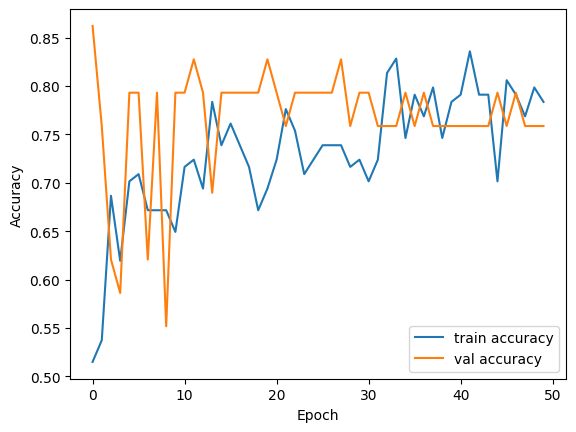

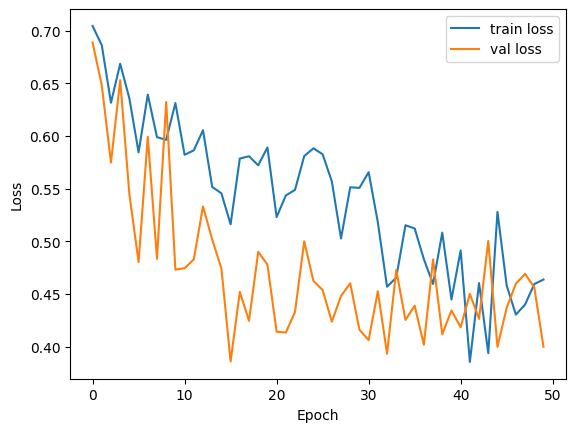

In [35]:
plt.figure()
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()